# Locations of PV household and DWD weather measurement stations

- aim: plot where weather data is available vs. where data is available on sunshine duration and weather

## Background

### Geographical location

- possible encoding of location:
    - city name
    - longitude/latitude
    - postal code (postleitzahl, plz)
>
- geographical information for Germany
    - [Repo1](https://github.com/isellsoap/deutschlandGeoJSON) GeoJSON including federal states (bundeslaender), and more (regierungsbezirke, kreise)
    - [Repo2](https://github.com/yetzt/postleitzahlen) GeoJSON for German postal codes
    - [Repo3 - deprecated](https://github.com/WZBSocialScienceCenter/plz_geocoord) longitude and latitude of german postal code centers (but 1 PLZ with wrong coordinates, some missing)
    - [Repo4](https://github.com/zauberware/postal-codes-json-xml-csv) longitude and latitude of german postal code centers

### Data on generation of solar energy
>
- PV household data from [openmeter platform (OM)](https://appstore.logarithmo.de/app/openmeterplatform/v1/demo/page-datenuebersicht?lang=DE)
    - for solar data select: 
        - Energietypen:**Strom** (power) 
        - Mess-Kategorie:**Erzeugung** (generation) 
        - Objekt-Kategorie:**Privat** (private)
    - tabular information downloaded stepwise manually (very tedious), as token for API did not work

### Weather data
>
- weather data from [Deutscher Wetterdienst (DWD)](https://opendata.dwd.de/climate_environment/CDC/observations_germany/climate/daily/)


## Task: Linking OM PV sensors and DWD weather stations

1. available data
- solar sensors from [OpenMeter platform](https://appstore.logarithmo.de/app/openmeterplatform/v1/demo/page-datenuebersicht?lang=DE)
    - information on postal code (plz), city, federal state 
    - no coordinates (longitude/latitude) available
    - note: sometimes issues with the data
        - leading zeros missing from plz postal codes (Sachsen, Thuringen, Sachsen-Anhalt, Brandenburg)
        - one sensor with wrong plz (86808 Buchloe)
        - one sensor missing plz (Sonstige Berlin)
        - sometimes federal state does not match (e.g. Bergen is Bayern, not Sachsen)
- weather stations with daily weather from [DWD](https://opendata.dwd.de/climate_environment/CDC/observations_germany/climate/daily/)
    - station list available [here](https://opendata.dwd.de/climate_environment/CDC/observations_germany/climate/daily/kl/recent/KL_Tageswerte_Beschreibung_Stationen.txt)
    - information on coordinates (longitude/latitude), city, federal state
    - no plz given
>
2. task: link PV sensors (plz) to weather station (coordinates)
- step 1: link plz postal codes to centers of these areas
    - [source](https://github.com/zauberware/postal-codes-json-xml-csv)
- step 2: calculate distances
    - here: calculate Euclidean distance and store minimum
- step 3: calculate real distance in kilometers
    - use haversine formula
        > [Background](https://en.wikipedia.org/wiki/Haversine_formula) for distance calculations from longitude and latitude: The haversine formula determines the great-circle distance between two points on a sphere given their longitudes and latitudes.


## Preparations

In [1]:
# general packages
from datetime import datetime
import pandas as pd
import numpy as np
import math

# plotting
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

# import packages for loading geojsons
import urllib.request 
import geojson

# fetch online files
import subprocess
import requests
import os
import re


In [2]:
# !pip install plotly
# !pip install geojson

## Functions

In [3]:
def prepare_outdir(out_path, verbose=False):
    """create (nested) output folders

    Args:
        out_path (string): directory (e.g. 'data', 'data/more_data/', '../data/')
        verbose (bool, optional): print more information. Defaults to False.
    """
    # get current path (to return to)
    path = os.getcwd()
    if verbose:
        print("Current path:", path)

    # iterate over all directories (if nested)
    my_path = out_path.split("/")
    if verbose:
        print("Output directory",my_path)
    curr_dir = "."
    while len(my_path) > 0:
        # change if last subdirectory is created
        if len(my_path) == 0 or my_path == [""]:
            break

        # track current (sub)directory
        curr_dir = curr_dir + "/" + my_path[0]
        if not my_path[0] in ("", ".") :
            # create subdirectory, if require
            if not os.path.isdir(my_path[0]):
                print("Created directory", curr_dir)
                os.mkdir(my_path[0])
            # change working directory to new subdirectory
            os.chdir(my_path[0])
        
        # remove current subdirectory from list
        if len(my_path) > 1:
            my_path = my_path[1:]
        else:
            break # my_path = []
    
    # go back to original working directory
    os.chdir(path)

In [4]:
def download_file(url, out_path):
    filename = url.split("/")[-1]

    # write information to local file
    prepare_outdir(out_path)
    webpage = requests.get(url, allow_redirects=True)
    outfile = open(out_path+filename, 'wb').write(webpage.content)
    outfile.close()
    
    return filename

In [5]:
def read_geojson(geojson_link, key_id, verbose=False):
    """
    read geoJSON file from URL and return geojson-object with plz postal code linked to area
    """
    # load postal code areas of Germany from .geojson file.
    with urllib.request.urlopen(geojson_link) as url:
        gj = geojson.load(url)
        # print exemplary entry
        if verbose:
            for item in gj['features']:
                print(item)
                break

    # adding postal code as 'id' for each postal code area in the geojson array
    # used by plotly to link postal code information to corresponding area     
    for i in range(len(gj['features'])):
        gj['features'][i]['id'] = gj['features'][i]['properties'][key_id] # postal code
    
    return gj


In [6]:
def haversine_distance_km(lat1, lon1, lat2, lon2):
    """
    calculate distance in kilometers for two points based on longitude and latitude
    """
    # generally used geo measurement function
    # https://stackoverflow.com/questions/639695/how-to-convert-latitude-or-longitude-to-meters
    # calculation acc. to Haversine formula - https://en.wikipedia.org/wiki/Haversine_formula 
    R = 6378.137 # Radius of earth in KM
    dLat = lat2 * math.pi / 180 - lat1 * math.pi / 180;
    dLon = lon2 * math.pi / 180 - lon1 * math.pi / 180;
    a = math.sin(dLat/2) * math.sin(dLat/2) + \
        math.cos(lat1 * math.pi / 180) * math.cos(lat2 * math.pi / 180) * \
        math.sin(dLon/2) * math.sin(dLon/2);
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1-a));
    d = R * c;
    return d  # kilometers

In [7]:
def link_om_pv_to_dwd_weather(om_pv_df, dwd_df):
    """link openmeter sensor plz to closest dwd measurement station coordinates"""

    # create new dataframe for connected PV sensors and DWD stations
    linked_df = om_pv_df.copy()
    linked_df["distance_km"] = float("inf")
    linked_df["dwd_stat_name"] = np.nan
    linked_df["dwd_stat_lon"] = np.nan
    linked_df["dwd_stat_lat"] = np.nan
    linked_df['dwd_stat_id'] = np.nan

    # collect closest weather station for each PV sensor
    for idx in range(len(om_pv_df)):
        if not np.isnan(om_pv_df.iloc[idx]["lat"]):
            point1 = np.array(om_pv_df.iloc[idx][["lat", "lon"]])
            min_dist = float("inf")
            candidate, loc, stat_id = None, None, None
            # check distance to all weather stations
            for jdx in range(len(dwd_df)):
                point2 = np.array(dwd_df.iloc[jdx][["geoBreite", "geoLaenge"]])
                dist = np.linalg.norm(point1-point2)
                # keep closest station
                if dist < min_dist:
                    min_dist = dist
                    candidate = np.array(dwd_df.iloc[jdx][["geoBreite", "geoLaenge"]])
                    loc = dwd_df.iloc[jdx]["Stationsname"].strip()
                    stat_id = dwd_df.iloc[jdx]["Stations_id"]

            # calculate distance in km instead of Euclidean distance
            linked_df.loc[idx, 'distance_km'] = haversine_distance_km(point1[0], point1[1], 
                                                                      candidate[0], candidate[1])
            linked_df.loc[idx, 'dwd_stat_name'] = loc
            linked_df.loc[idx, 'dwd_stat_lon'] = candidate[1]
            linked_df.loc[idx, 'dwd_stat_lat'] = candidate[0]
            linked_df.loc[idx, 'dwd_stat_id'] = stat_id
            
    return linked_df


## Geographical data for Germany - GeoJSONs


In [8]:
# germany with federal states (high resolution)
geojson_link = "https://raw.githubusercontent.com/isellsoap/deutschlandGeoJSON/main/2_bundeslaender/2_hoch.geo.json"
germany_gj = read_geojson(geojson_link, "name") # name = Bundesland

# germany with plz postal codes (high resolution)
geojson_link_plz = "https://raw.githubusercontent.com/yetzt/postleitzahlen/main/data/postleitzahlen.small.geojson"
germany_plz_gj = read_geojson(geojson_link_plz, "postcode") # postcode = plz


## PLZ coordinates (source 1) - deprecated

In [9]:
# read PLZ centers (v1)
url = "https://raw.githubusercontent.com/WZBSocialScienceCenter/plz_geocoord/master/plz_geocoord.csv"
out_path = "../data/locations/"

# save file to disk create df for plz coordinates
filename = download_file(url, out_path)
plz_coordinates2 = pd.read_csv(out_path+filename)

plz_coordinates2.head(2)

,Unnamed: 0,lat,lng
0,1067,51.057550,13.717065
1,1069,51.039135,13.737675


In [10]:

# rename columns
plz_coordinates2.columns = ["plz", "lat", "lon"]

# correct plz postal code formatting to have leading zeros
plz_coordinates2.plz = ["%05d" % x for x in plz_coordinates2.plz]

In [11]:
# # choropleth plot of plz postal code regions displaying the average price/sqft of living space.
# fig = px.choropleth_mapbox(plz_coordinates, geojson=germany_plz_gj, locations="plz", color='lon',
#                            color_continuous_scale="plasma_r",#"YlOrRd",
#                            mapbox_style="carto-positron", #"open-street-map",
#                            zoom=4.8,
#                            center=dict(lat=51.3, lon=10.5), # center map on Germany
#                            opacity=.85,
#                            hover_data=['lon', 'lat'],
#                         #    labels={'column':'$ per sqft'},
#                            width=500,
#                            height=500
#                           )
# fig.update_layout(margin={"r":0,"t":0,"l":0,"b":0}) # Removing white borders around map
# fig.show()



> Observations
>> erroneous lat & lon coordinates of center wrong for plz 16949 > e.g. correct lat by 2!
>> center coordinates for some plz missing

## PLZ coordinates (source 2) - better

In [12]:
### PLZ coordinates (source 1) - deprecated
url = "https://github.com/zauberware/postal-codes-json-xml-csv/raw/6cf0f0cd1bfcece547c6655ab013d8db55a2ee89/data/DE.zip"

# save file to disk create df for plz coordinates
filename = download_file(url, out_path)
subprocess.run(["unzip", "-o", out_path+filename, "-d", out_path+filename[:filename.rfind(".")]])

Archive:  ../data/locations/DE.zip
  inflating: ../data/locations/DE/zipcodes.de.json  
  inflating: ../data/locations/DE/zipcodes.de.xml  
  inflating: ../data/locations/DE/zipcodes.de.csv  


CompletedProcess(args=['unzip', '-o', '../data/locations/DE.zip', '-d', '../data/locations/DE'], returncode=0)

In [13]:
plz_coordinates = pd.read_csv(out_path+filename[:filename.rfind(".")]+"/zipcodes.de.csv")

In [14]:
plz_coordinates.head(2)

,country_code,zipcode,place,state,state_code,province,province_code,community,community_code,latitude,longitude
0,DE,1945,Guteborn,Brandenburg,BB,NaN,0.0,Landkreis Oberspreewald-Lausitz,12066.0,51.4167,13.9333
1,DE,1945,Kroppen,Brandenburg,BB,NaN,0.0,Landkreis Oberspreewald-Lausitz,12066.0,51.3833,13.8000


In [15]:
# correct plz postal code formatting to have leading zeros
plz_coordinates.zipcode = ["%05d" % x for x in plz_coordinates.zipcode]
plz_coordinates.head(2)


,country_code,zipcode,place,state,state_code,province,province_code,community,community_code,latitude,longitude
0,DE,01945,Guteborn,Brandenburg,BB,NaN,0.0,Landkreis Oberspreewald-Lausitz,12066.0,51.4167,13.9333
1,DE,01945,Kroppen,Brandenburg,BB,NaN,0.0,Landkreis Oberspreewald-Lausitz,12066.0,51.3833,13.8000


In [16]:
plz_coordinates["plz3digits"] = [x[:3] for x in plz_coordinates.zipcode]
plz_coordinates["plz3digits"] = plz_coordinates["plz3digits"].astype(int)
plz_coordinates["plz2digits"] = [x[:2] for x in plz_coordinates.zipcode]
plz_coordinates["plz2digits"] = plz_coordinates["plz2digits"].astype(int)


## Plot zipcode map

In [17]:
# choropleth plot of plz postal code regions displaying the average price/sqft of living space.
fig = px.choropleth_mapbox(plz_coordinates, geojson=germany_plz_gj, locations="zipcode", color='latitude',
                           color_continuous_scale="plasma_r",#"YlOrRd",
                           mapbox_style="carto-positron", #"open-street-map",
                           zoom=4.8,
                           center=dict(lat=51.3, lon=10.5), # center map on Germany
                           opacity=.85,
                           hover_data=['longitude', 'latitude'],
                        #    labels={'column':'$ per sqft'},
                           width=500,
                           height=500
                          )
fig.update_layout(margin={"r":0,"t":0,"l":0,"b":0}) # Removing white borders around map
plt.clf() # clear figure from cache, do not display here (too big)
# fig.show()

<Figure size 640x480 with 0 Axes>

In [18]:
# choropleth plot of plz postal code regions displaying the average price/sqft of living space.
fig = px.choropleth_mapbox(plz_coordinates, geojson=germany_plz_gj, locations="zipcode", color='plz3digits',
                           color_continuous_scale="plasma_r",#"YlOrRd",
                           mapbox_style="carto-positron", #"open-street-map",
                           zoom=4.8,
                           center=dict(lat=51.3, lon=10.5), # center map on Germany
                           opacity=.85,
                           hover_data=['longitude', 'latitude'],
                        #    labels={'column':'$ per sqft'},
                           width=500,
                           height=500
                          )
fig.update_layout(margin={"r":0,"t":0,"l":0,"b":0}) # Removing white borders around map
plt.clf() # clear figure from cache, do not display here (too big)
# fig.show()


<Figure size 640x480 with 0 Axes>

In [19]:
plz_list_1 = []
plz_list_2 = plz_coordinates["zipcode"]
for i in range(len(germany_plz_gj['features'])):
    plz_list_1.append(germany_plz_gj['features'][i]['id'])

print("PLZ range of map: %s - %s (n=%d)" % (min(plz_list_1), max(plz_list_1), len(set(plz_list_1)))) # 8116
print("PLZ range of map: %s - %s (n=%d)" % (min(plz_list_2), max(plz_list_2), len(set(plz_list_2)))) # 16478


PLZ range of map: 01067 - 99998 (n=8116)
PLZ range of map: 01067 - 99998 (n=8308)


> Observations
>> also center coordinates for some plz missing (not sooo relevant here, hopefully)

## Geographical Information from OpenMeter data platform

In [20]:
# extract location information available for sensors listed on openmeter platform
# data copied manually - missing delimiters, leading zeros missing for plz postal codes
omp_plzs = []
state_remainders = set([])
with open("../data/locations/openmeter_data_downloaded_2023-07-24_shouldbe_n412.txt") as infile:
    for line in infile:
        if line.strip() != "":
            info = line.strip().split("Deutschland")[-1]

            # identify postal code plz and city name
            try: 
                # missing delimiter - filter plz and city by regular expressions
                plz = re.search('[^0-9]{1}[0-9]{5}', info).group(0)[1:]
                if "PIRNA" in info:
                    city = "Pirna"
                    remainder = info.split(plz)[0].replace(city, "").replace("PIRNA", "")
                elif "Stadthagen Habichhorst-Blyinghausen" in info:
                    city = "Stadthagen Habichhorst-Blyinghausen"
                    remainder = info.split(plz)[0].replace(city, "")
                elif " " in info and "(" in info:
                    # print("?", info)
                    city = re.search('([A-Z]{,2}[^A-Z^0-9]{1,} ){1,}[()][A-Z]{,2}[^A-Z^0-9]{1,}[)][0-9]{1}', info).group(0)[:-1]
                    remainder = info.split(plz)[0].replace(city, "")
                    # print(">", city)
                elif len(info.split(" "))>1 and not "Dorsten" in info:
                    # print("?", info)
                    city = re.search('([A-Z]{,2}[^A-Z^0-9]{1,} ){1,}([A-Z]{,3} ){,1}([A-Z]{,2}[^A-Z^0-9]-){,1}[A-Z]{,2}[^A-Z^0-9]{1,}[0-9]{1}', info).group(0)[:-1]
                    # city = re.search('([A-Z]{,2}[^A-Z^0-9]{1,} ){1,}([A-Z]{,3} ){,1}[A-Z]{,2}[^A-Z^0-9]{1,}[0-9]{1}', info).group(0)[:-1]
                    remainder = info.split(plz)[0].replace(city, "")
                    # print(">", city)
                else:
                    city = re.search('[A-Z]{,2}[^A-Z^0-9]{2,}[0-9]{1}', info).group(0)[:-1]
                    remainder = info.split(plz)[0].replace(city, "")
                    if remainder.endswith("-"):
                        # print("!", city)
                        city = re.search('[A-Z]{,2}[^A-Z^0-9]{2,}-[A-Z]{,2}[^A-Z^0-9]{2,}[0-9]{1}', info).group(0)[:-1]
                        remainder = info.split(plz)[0].replace(city, "")
                    elif "Bad " in remainder:
                        city = remainder[remainder.find("Bad "):] + city
                        # print("!", city)
                        remainder = remainder[:remainder.find("Bad ")]
                
                # remainder == "" for BerlinBerlin and BremenBremen
                if remainder == "" and "BerlinBerlin" in info:
                    remainder = "Berlin"
                elif remainder == "" and "BremenBremen" in info:
                    remainder = "Bremen"
                state_remainders.add(remainder)

                # 0 in PLZ omitted in table - correct for this!
                # 0-PLZs located in Sachsen, Sachsen-Anhalt, Brandenburg & Thueringen
                # error in data: Bergen is actually in Bayern, not in Sachsen
                if "GEra" in info or "Ertern" in info or "Artern" in info or "Elsterwerda" in info or\
                    ("Sachsen" in info and not "Anhalt" in info and not "Bergen" in info):
                        plz = "0"+plz[:4]
                        # print(plz, info)
                sensor_id, start_date, end_date = line[:36], line[36:46], line[46:56]
                omp_plzs.append([plz, city, remainder, sensor_id, start_date, end_date])
            except:
                print("No PLZ for", line.strip())

print("\n%d Federal states: %s\n" % (len(state_remainders), ", ".join(sorted(state_remainders))))

omp_pv_sensors_df = pd.DataFrame(omp_plzs)
omp_pv_sensors_df.columns = ["plz", "city", "state", "sensor_id", "start_date", "end_date"]
omp_pv_sensors_df["num"] = 1


No PLZ for 2d0fa9c4-6fd3-485b-aee9-16ce554f963e2023-07-142023-07-24ErzeugungKWhWirkarbeitPrivatHaushalt DeutschlandSonstigeBerlin

16 Federal states: Baden-Wuerttemberg, Bayern, Berlin, Brandenburg, Bremen, Hamburg, Hessen, Mecklenburg-Vorpommern, Niedersachsen, Nordrhein-Westfalen, Rheinland-Pfalz, Saarland, Sachsen, Sachsen-Anhalt, Schleswig-Holstein, Thüringen



In [21]:
omp_pv_sensors_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 417 entries, 0 to 416
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   plz         417 non-null    object
 1   city        417 non-null    object
 2   state       417 non-null    object
 3   sensor_id   417 non-null    object
 4   start_date  417 non-null    object
 5   end_date    417 non-null    object
 6   num         417 non-null    int64 
dtypes: int64(1), object(6)
memory usage: 22.9+ KB


In [22]:
omp_pv_sensors_df.head()

,plz,city,state,sensor_id,start_date,end_date,num
0,52080,Aachen,Nordrhein-Westfalen,46b430e9-d28e-4470-9a18-9b74e6f9353c,2018-11-19,2023-07-05,1
1,52080,Aachen,Nordrhein-Westfalen,a4604486-4623-4741-b8f3-efc8315bb168,2018-11-19,2023-05-24,1
2,18211,Admannshagen-Bargeshagen,Mecklenburg-Vorpommern,55de06da-6652-4f4b-a076-2dbc42eacd62,2020-09-08,2023-07-05,1
3,18211,Admannshagen-Bargeshagen,Mecklenburg-Vorpommern,6fdead49-c75f-4686-935f-33cd0d51d720,2020-09-08,2022-07-11,1
4,53347,Alfter,Nordrhein-Westfalen,7ea4dc02-34b1-4f2b-86a0-677b32246985,2019-02-26,2023-07-05,1


### Convert plz to lon/lat

In [23]:
# create dictionaries to convert plz postal code to longitude & latitude 
my_dict = plz_coordinates[["zipcode", "latitude", "longitude"]]
lat_dict = dict(zip(my_dict.zipcode, my_dict.latitude))
lon_dict = dict(zip(my_dict.zipcode, my_dict.longitude))

In [24]:
# create entries for missing plz postal codes
for plz in ("65561", "86808"):
    lon_dict[plz] = np.nan
    lat_dict[plz] = np.nan

# get longitude and latitude for the plz postal code center
omp_pv_sensors_df["lon"] = [lon_dict[x] for x in omp_pv_sensors_df["plz"]]
omp_pv_sensors_df["lat"] = [lat_dict[x] for x in omp_pv_sensors_df["plz"]]

In [25]:
omp_pv_sensors_df.head()

,plz,city,state,sensor_id,start_date,end_date,num,lon,lat
0,52080,Aachen,Nordrhein-Westfalen,46b430e9-d28e-4470-9a18-9b74e6f9353c,2018-11-19,2023-07-05,1,6.1642,50.7793
1,52080,Aachen,Nordrhein-Westfalen,a4604486-4623-4741-b8f3-efc8315bb168,2018-11-19,2023-05-24,1,6.1642,50.7793
2,18211,Admannshagen-Bargeshagen,Mecklenburg-Vorpommern,55de06da-6652-4f4b-a076-2dbc42eacd62,2020-09-08,2023-07-05,1,11.8778,54.0455
3,18211,Admannshagen-Bargeshagen,Mecklenburg-Vorpommern,6fdead49-c75f-4686-935f-33cd0d51d720,2020-09-08,2022-07-11,1,11.8778,54.0455
4,53347,Alfter,Nordrhein-Westfalen,7ea4dc02-34b1-4f2b-86a0-677b32246985,2019-02-26,2023-07-05,1,7.0167,50.7333


In [26]:
# color by filtered plz postal code
fig = px.scatter_mapbox(omp_pv_sensors_df, lat="lat", lon="lon", hover_name="city", # hover_data=["col1", "col2"], 
                        center=dict(lat=51.3, lon=10.5), # center map on Germany
                        zoom=3.9, width=400, height=300, 
                        opacity=0.55, color_discrete_sequence=["darkblue"])#, color="column")
fig.update_layout(mapbox_style="open-street-map")
fig.update_layout(margin={"r":10,"t":10,"l":10,"b":10}) # white margin around figure
fig.show()


In [27]:
# color areas for postal codes accoding to number of linked PV sensors
plz_count = omp_pv_sensors_df.groupby("plz").count().reset_index()
plz_count

,plz,city,state,sensor_id,start_date,end_date,num,lon,lat
0,01129,1,1,1,1,1,1,1,1
1,01157,1,1,1,1,1,1,1,1
2,01737,1,1,1,1,1,1,1,1
3,01796,1,1,1,1,1,1,1,1
4,04680,1,1,1,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...
342,99099,1,1,1,1,1,1,1,1
343,99441,1,1,1,1,1,1,1,1
344,99631,1,1,1,1,1,1,1,1
345,99755,1,1,1,1,1,1,1,1


In [28]:

# choropleth plot of plz postal code regions displaying the average price/sqft of living space.
fig = px.choropleth_mapbox(plz_count, geojson=germany_plz_gj, locations="plz", color='num',
                           color_continuous_scale="plasma_r",#"YlOrRd",
                           mapbox_style="carto-positron", #"open-street-map",
                           zoom=4.8,
                           center=dict(lat=51.3, lon=10.5), # center map on Germany
                           opacity=.85,
                           hover_data=['plz', 'num'],
                        #    labels={'column':'$ per sqft'},
                           width=500,
                           height=500
                          )
fig.update_layout(margin={"r":0,"t":0,"l":0,"b":0}) # Removing white borders around map
plt.clf() # clear figure from cache, do not display here (too big)
# fig.show()

<Figure size 640x480 with 0 Axes>

## Weather data locations (hourly)

In [29]:
locations_file_weather_hourly = "../data/weather-hourly/ST_solar_hourly_current_dwd_stations_ST_ST_solar_hourly_data.csv"
dwd_locations_hourly_df = pd.read_csv(locations_file_weather_hourly)
dwd_locations_hourly_df.head()

,Stations_id,von_datum,bis_datum,Stationshoehe,geoBreite,geoLaenge,Stationsname,Bundesland
0,183,19810101,20230630,42,54.6791,13.4344,Arkona,Mecklenburg-Vorpommern
1,662,19580101,20230630,81,52.2915,10.4464,Braunschweig,Niedersachsen
2,853,19810101,20230630,416,50.7913,12.8720,Chemnitz,Sachsen
3,1048,19960901,20230630,228,51.1278,13.7543,Dresden-Klotzsche,Sachsen
4,1358,19580101,20230630,1213,50.4283,12.9536,Fichtelberg,Sachsen


In [30]:
dwd_locations_hourly_df.describe()

,Stations_id,von_datum,bis_datum,Stationshoehe,geoBreite,geoLaenge
count,23.000000,2.300000e+01,23.0,23.000000,23.000000,23.000000
mean,3469.173913,1.976627e+07,20230630.0,303.695652,51.054548,11.152765
std,1882.823428,1.699660e+05,0.0,328.227947,2.200877,2.442035
min,183.000000,1.945123e+07,20230630.0,5.000000,47.695200,6.658300
25%,1829.500000,1.959510e+07,20230630.0,62.000000,49.359550,9.374350
50%,3987.000000,1.980010e+07,20230630.0,239.000000,50.791300,11.694600
75%,5014.000000,1.986010e+07,20230630.0,422.000000,52.636150,13.207700
max,5906.000000,2.005010e+07,20230630.0,1213.000000,54.679100,14.950600


In [31]:
# color by filtered plz postal code
fig = px.scatter_mapbox(dwd_locations_hourly_df, lat="geoBreite", lon="geoLaenge", # hover_name="house_id", hover_data=["col1", "col2"], 
                        center=dict(lat=51.3, lon=10.5), # center map on Germany
                        zoom=3.9, width=400, height=300, 
                        opacity=0.55, color_discrete_sequence=["red"])#, color="column")
fig.update_layout(mapbox_style="open-street-map")
fig.update_layout(margin={"r":10,"t":10,"l":10,"b":10}) # white margin around figure
fig.show()


## Weather data locations (daily)

In [32]:
locations_file_weather_daily = "../data/weather-daily/KL_Tageswerte_Beschreibung_Stationen.txt"

daily_weather = []
# read data individually due to German special characters
# columns separated by spaces - but city names also may contain spaces
outfile = open(locations_file_weather_daily+"_temp", 'w')
with open(locations_file_weather_daily, 'rb') as infile:
    for line in infile: 
        if not line.decode('windows-1252').startswith("---"):
            outfile.write(line.strip().decode('windows-1252') + "\n")
            data = line.strip().decode('windows-1252').replace("  ", " ").replace("  ", " ").replace("  ", " ").replace("  ", " ")
            data = data.split(" ")
            info = data[:6]
            info.append(" ".join(data[6:-1]))
            info.append(data[-1])
            daily_weather.append(info)
outfile.close()
header = daily_weather.pop(0)
print(pd.DataFrame(daily_weather).head())

       0         1         2    3        4        5  \
0  00001  19370101  19860630  478  47.8413   8.8493   
1  00003  18910101  20110331  202  50.7827   6.0941   
2  00011  19800901  20200930  680  47.9736   8.5205   
3  00044  19690101  20230719   44  52.9336   8.2370   
4  00052  19690101  20011231   46  53.6623  10.1990   

                             6                    7  
0                       Aach      Baden-Württemberg  
1                     Aachen    Nordrhein-Westfalen  
2  Donaueschingen (Landeplatz)    Baden-Württemberg  
3                Großenkneten         Niedersachsen  
4        Ahrensburg-Wulfsdorf    Schleswig-Holstein  


In [33]:
df_locations_daily = pd.DataFrame(daily_weather)
df_locations_daily.columns = header

In [34]:
df_locations_daily.tail()

,Stations_id,von_datum,bis_datum,Stationshoehe,geoBreite,geoLaenge,Stationsname,Bundesland
1344,19607,19720501,20010430,615,50.6952,13.4972,Cämmerswalde-Rauschenbach,Sachsen
1345,19617,19410101,20061231,310,49.7391,10.6039,Burghaslach,Bayern
1346,19631,18810601,19691231,268,50.8083,10.2294,Salzungen,Thüringen
1347,19647,19510101,20051031,178,49.4547,8.9794,Eberbach/Neckar,Baden-Württemberg
1348,19774,19710819,19940228,174,51.4814,10.8057,Nordhausen (Umspannwerk),Thüringen


In [35]:
df_locations_daily.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1349 entries, 0 to 1348
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Stations_id    1349 non-null   object
 1   von_datum      1349 non-null   object
 2   bis_datum      1349 non-null   object
 3   Stationshoehe  1349 non-null   object
 4   geoBreite      1349 non-null   object
 5   geoLaenge      1349 non-null   object
 6   Stationsname   1349 non-null   object
 7   Bundesland     1349 non-null   object
dtypes: object(8)
memory usage: 84.4+ KB


In [36]:
# correct formatting for date and geographic columns
df_locations_daily.geoBreite = df_locations_daily.geoBreite.astype(float)
df_locations_daily.geoLaenge = df_locations_daily.geoLaenge.astype(float)
df_locations_daily.von_datum = pd.to_datetime(df_locations_daily.von_datum, format='%Y%m%d')
df_locations_daily.bis_datum = pd.to_datetime(df_locations_daily.bis_datum, format='%Y%m%d')

In [37]:
# color by filtered plz postal code
fig = px.scatter_mapbox(df_locations_daily, lat="geoBreite", lon="geoLaenge", # hover_name="house_id", hover_data=["col1", "col2"], 
                        center=dict(lat=51.3, lon=10.5), # center map on Germany
                        zoom=3.9, width=400, height=300,
                        opacity=0.55, color_discrete_sequence=["red"])#, color="column")
fig.update_layout(mapbox_style="open-street-map")
fig.update_layout(margin={"r":10,"t":10,"l":10,"b":10}) # white margin around figure
fig.show()


In [38]:
df_locations_daily.bis_datum.head()

0   1986-06-30
1   2011-03-31
2   2020-09-30
3   2023-07-19
4   2001-12-31
Name: bis_datum, dtype: datetime64[ns]

### Filter daily weather data by date (recent data)

In [39]:
recent_daily_data = df_locations_daily[df_locations_daily.bis_datum > datetime(2023, 7, 1)]
recent_daily_data.reset_index(drop=True, inplace=True)

In [40]:
print(df_locations_daily.shape)
print(recent_daily_data.shape)

(1349, 8)
(563, 8)


In [41]:
# color by filtered plz postal code
fig = px.scatter_mapbox(recent_daily_data, lat="geoBreite", lon="geoLaenge", # hover_name="house_id", hover_data=["col1", "col2"], 
                        center=dict(lat=51.3, lon=10.5), # center map on Germany
                        zoom=3.9, width=400, height=300, opacity=0.55, color_discrete_sequence=["red"])#, color="column")
fig.update_layout(mapbox_style="open-street-map")
fig.update_layout(margin={"r":10,"t":10,"l":10,"b":10}) # white margin around figure
fig.show()


In [42]:
# ids of dwd measurement stations providing recent data
", ".join(recent_daily_data.Stations_id)

'00044, 00073, 00078, 00090, 00091, 00096, 00102, 00125, 00131, 00142, 00150, 00151, 00154, 00161, 00164, 00167, 00183, 00191, 00197, 00198, 00217, 00222, 00232, 00257, 00259, 00282, 00294, 00298, 00303, 00314, 00320, 00330, 00342, 00368, 00377, 00379, 00390, 00400, 00403, 00420, 00427, 00433, 00445, 00460, 00535, 00555, 00591, 00596, 00603, 00617, 00619, 00642, 00656, 00662, 00691, 00701, 00704, 00722, 00755, 00757, 00760, 00766, 00769, 00788, 00817, 00840, 00850, 00853, 00856, 00867, 00880, 00891, 00896, 00917, 00953, 00963, 00983, 00991, 01001, 01011, 01013, 01048, 01050, 01051, 01052, 01072, 01078, 01103, 01107, 01161, 01197, 01200, 01207, 01214, 01224, 01246, 01255, 01262, 01266, 01270, 01279, 01297, 01300, 01303, 01327, 01332, 01339, 01346, 01357, 01358, 01379, 01411, 01420, 01424, 01443, 01451, 01468, 01490, 01503, 01504, 01526, 01544, 01550, 01572, 01580, 01584, 01587, 01590, 01602, 01605, 01612, 01639, 01645, 01666, 01684, 01691, 01694, 01721, 01735, 01736, 01757, 01759, 01766

### Filter daily weather data by date (recent and longterm data)

In [43]:
recent_long_daily_data = recent_daily_data[recent_daily_data.von_datum <= datetime(2005, 12, 31)]
recent_long_daily_data.reset_index(drop=True, inplace=True)


In [44]:
print(recent_daily_data.shape)
print(recent_long_daily_data.shape)

(563, 8)
(478, 8)


In [45]:
# color by filtered plz postal code
fig = px.scatter_mapbox(recent_long_daily_data, lat="geoBreite", lon="geoLaenge", # hover_name="house_id", hover_data=["col1", "col2"], 
                        center=dict(lat=51.3, lon=10.5), # center map on Germany
                        zoom=3.9, width=400, height=300, opacity=0.55, color_discrete_sequence=["red"])#, color="column")
fig.update_layout(mapbox_style="open-street-map")
fig.update_layout(margin={"r":10,"t":10,"l":10,"b":10}) # white margin around figure
fig.show()


In [46]:
# ids of dwd measurement stations providing recent data
", ".join(recent_long_daily_data.Stations_id)

'00044, 00073, 00078, 00090, 00091, 00102, 00125, 00131, 00142, 00150, 00151, 00154, 00161, 00164, 00167, 00183, 00191, 00197, 00198, 00217, 00222, 00232, 00257, 00259, 00282, 00294, 00298, 00303, 00314, 00320, 00330, 00368, 00377, 00379, 00390, 00400, 00403, 00420, 00427, 00433, 00445, 00460, 00535, 00555, 00591, 00596, 00603, 00617, 00619, 00642, 00656, 00662, 00691, 00701, 00704, 00722, 00755, 00757, 00760, 00766, 00769, 00788, 00817, 00840, 00850, 00853, 00856, 00867, 00880, 00891, 00896, 00917, 00953, 00963, 00991, 01001, 01011, 01013, 01048, 01050, 01051, 01052, 01072, 01078, 01103, 01107, 01161, 01197, 01200, 01207, 01214, 01224, 01255, 01262, 01266, 01270, 01279, 01297, 01300, 01303, 01327, 01332, 01339, 01346, 01357, 01358, 01379, 01411, 01420, 01424, 01443, 01451, 01468, 01490, 01503, 01504, 01526, 01544, 01550, 01572, 01580, 01587, 01590, 01602, 01605, 01612, 01639, 01645, 01666, 01684, 01691, 01694, 01721, 01735, 01736, 01757, 01759, 01766, 01803, 01832, 01863, 01869, 01963

### Filter daily weather data by date (recent and midterm data)

In [47]:
recent_general_daily_data = recent_daily_data[recent_daily_data.von_datum <= datetime(2015, 1, 1)]
recent_general_daily_data.reset_index(drop=True, inplace=True)
print(recent_daily_data.shape)
print(recent_general_daily_data.shape)

(563, 8)
(541, 8)


In [48]:
# color by filtered plz postal code
fig = px.scatter_mapbox(recent_general_daily_data, lat="geoBreite", lon="geoLaenge", # hover_name="house_id", hover_data=["col1", "col2"], 
                        center=dict(lat=51.3, lon=10.5), # center map on Germany
                        zoom=3.9, width=400, height=300, opacity=0.55, color_discrete_sequence=["red"])#, color="column")
fig.update_layout(mapbox_style="open-street-map")
fig.update_layout(margin={"r":10,"t":10,"l":10,"b":10}) # white margin around figure
fig.show()

In [49]:
# ids of dwd measurement stations providing recent data
", ".join(recent_general_daily_data.Stations_id)

'00044, 00073, 00078, 00090, 00091, 00102, 00125, 00131, 00142, 00150, 00151, 00154, 00161, 00164, 00167, 00183, 00191, 00197, 00198, 00217, 00222, 00232, 00257, 00259, 00282, 00294, 00298, 00303, 00314, 00320, 00330, 00342, 00368, 00377, 00379, 00390, 00400, 00403, 00420, 00427, 00433, 00445, 00460, 00535, 00555, 00591, 00596, 00603, 00617, 00619, 00642, 00656, 00662, 00691, 00701, 00704, 00722, 00755, 00757, 00760, 00766, 00769, 00788, 00817, 00840, 00850, 00853, 00856, 00867, 00880, 00891, 00896, 00917, 00953, 00963, 00983, 00991, 01001, 01011, 01013, 01048, 01050, 01051, 01052, 01072, 01078, 01103, 01107, 01161, 01197, 01200, 01207, 01214, 01224, 01255, 01262, 01266, 01270, 01279, 01297, 01300, 01303, 01327, 01332, 01339, 01346, 01357, 01358, 01379, 01411, 01420, 01424, 01443, 01451, 01468, 01490, 01503, 01504, 01526, 01544, 01550, 01572, 01580, 01584, 01587, 01590, 01602, 01605, 01612, 01639, 01645, 01666, 01684, 01691, 01694, 01721, 01735, 01736, 01757, 01759, 01766, 01803, 01832

In [50]:
recent_general_daily_data.head()

,Stations_id,von_datum,bis_datum,Stationshoehe,geoBreite,geoLaenge,Stationsname,Bundesland
0,00044,1969-01-01,2023-07-19,44,52.9336,8.2370,Großenkneten,Niedersachsen
1,00073,1959-03-01,2023-07-19,340,48.6159,13.0506,Aldersbach-Kriestorf,Bayern
2,00078,1961-01-01,2023-07-19,64,52.4853,7.9125,Alfhausen,Niedersachsen
3,00090,1988-02-19,2023-07-19,305,50.7557,9.2583,Alsfeld,Hessen
4,00091,1978-11-01,2023-07-19,300,50.7446,9.3450,Alsfeld-Eifa,Hessen


## PV vs. Weather

In [51]:
# color by filtered plz postal code
# red = weather data
fig2 = px.scatter_mapbox(recent_long_daily_data, lat="geoBreite", lon="geoLaenge", 
                         hover_name="Stationsname", #hover_data=["col1", "col2"], 
                         zoom=5, width=800, height=600, 
                         opacity=0.55, color_discrete_sequence=["red"])#, color="column")
# blue = solar data
fig = px.scatter_mapbox(omp_pv_sensors_df, lat="lat", lon="lon", 
                        hover_name="city", # hover_data=["col1", "col2"], 
                        center=dict(lat=51.3, lon=10.5), # center map on Germany
                        zoom=5, width=800, height=600, 
                        opacity=0.55, color_discrete_sequence=["darkblue"])#, color="column")
fig.add_trace(fig2.data[0])

fig.update_layout(mapbox_style="open-street-map")
fig.update_layout(margin={"r":10,"t":10,"l":10,"b":10}) # white margin around figure
fig.show()


In [52]:
omp_pv_sensors_df.columns

Index(['plz', 'city', 'state', 'sensor_id', 'start_date', 'end_date', 'num',
       'lon', 'lat'],
      dtype='object')

In [53]:
recent_long_daily_data.columns

Index(['Stations_id', 'von_datum', 'bis_datum', 'Stationshoehe', 'geoBreite',
       'geoLaenge', 'Stationsname', 'Bundesland'],
      dtype='object')

### Connecting PV sensor location and nearest daily weather station

In [54]:
# create new dataframe for connected PV sensors and DWD stations
om_dwd_daily_dist_df = link_om_pv_to_dwd_weather(omp_pv_sensors_df, recent_long_daily_data)

In [55]:
# location without linked weather sensor (no lon/lat information for this plz postal code)
om_dwd_daily_dist_df[om_dwd_daily_dist_df.distance_km==float("inf")]


,plz,city,state,sensor_id,start_date,end_date,num,lon,lat,distance_km,dwd_stat_name,dwd_stat_lon,dwd_stat_lat,dwd_stat_id
68,86808,Buchloe,Bayern,b50ba775-9f69-491d-b901-3272c4b77255,2022-07-14,2023-07-05,1,NaN,NaN,inf,NaN,NaN,NaN,NaN


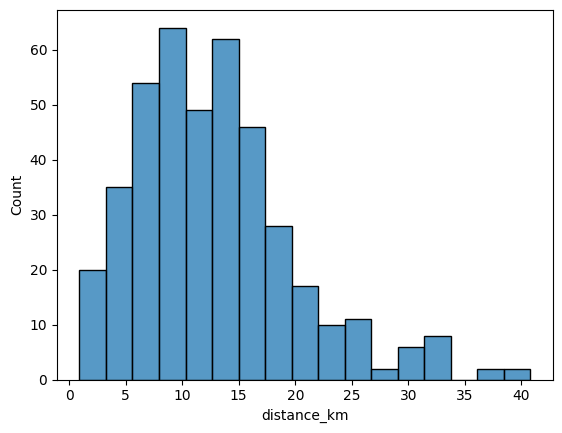

In [56]:
# distances of the solar sensors to the nearest weather station
sns.histplot(om_dwd_daily_dist_df.distance_km)
plt.show()

In [57]:
# max distance to a weather sensor
om_dwd_daily_dist_df.distance_km[om_dwd_daily_dist_df.distance_km!=float("inf")].max()

40.78921740894982

In [58]:
# sensors with nearby dwd weather station (<10km)
om_dwd_daily_dist_df[om_dwd_daily_dist_df.distance_km < 10].sort_values(by="distance_km")

,plz,city,state,sensor_id,start_date,end_date,num,lon,lat,distance_km,dwd_stat_name,dwd_stat_lon,dwd_stat_lat,dwd_stat_id
218,93138,Lappersdorf,Bayern,bdd64ade-f9fd-411b-a866-4c11a6a05be2,2021-03-05,2022-07-29,1,12.0913,49.0469,0.915493,Regensburg,12.1019,49.0425,04104
165,25856,Hattstedt,Schleswig-Holstein,066f2e84-5a9c-4b94-bcb3-7396e3856135,2022-07-14,2022-10-12,1,9.0333,54.5333,0.936342,Hattstedt,9.0425,54.5268,07298
10,56626,Andernach,Rheinland-Pfalz,4c376739-b1e2-4995-a966-69d6a43cb4d1,2019-10-22,2023-05-24,1,7.4042,50.4311,1.402161,Andernach,7.4202,50.4237,00161
228,94227,Lindberg,Bayern,379530c9-fb7b-47f4-821b-cbfaf50c632d,2019-10-04,2023-05-24,1,13.2542,49.0368,1.507525,Zwiesel,13.2385,49.0280,05800
234,94227,Lindberg,Bayern,379530c9-fb7b-47f4-821b-cbfaf50c632d,2019-10-04,2023-05-24,1,13.2542,49.0368,1.507525,Zwiesel,13.2385,49.0280,05800
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,27386,Hemslingen,Niedersachsen,7057f632-4dd3-48ed-b69f-7097cef6d87e,2018-08-31,2023-07-05,1,9.4726,53.0900,9.874367,Rotenburg (Wümme),9.3398,53.1289,04275
58,53127,Bonn,Nordrhein-Westfalen,17a567b0-b350-40bf-872c-7ae7ee473caf,2020-02-20,2023-07-05,1,7.0668,50.7112,9.877164,Königswinter-Heiderhof,7.2040,50.7293,00603
70,35418,Buseck,Hessen,3e828a6b-23b9-4774-997f-1011c470076b,2020-12-02,2023-05-24,1,8.7830,50.6148,9.934401,Gießen/Wettenberg,8.6439,50.6017,01639
114,45357,Essen,Nordrhein-Westfalen,44995b18-bef1-4248-8daa-ac40391ca940,2020-12-14,2023-05-24,1,6.9402,51.4918,9.947394,Essen-Bredeney,6.9677,51.4041,01303


In [59]:
# list of sensors with nearby weather stations (< 10km distance)
",".join(om_dwd_daily_dist_df[om_dwd_daily_dist_df.distance_km < 10].sort_values(by="distance_km")["sensor_id"].to_list())


'bdd64ade-f9fd-411b-a866-4c11a6a05be2,066f2e84-5a9c-4b94-bcb3-7396e3856135,4c376739-b1e2-4995-a966-69d6a43cb4d1,379530c9-fb7b-47f4-821b-cbfaf50c632d,379530c9-fb7b-47f4-821b-cbfaf50c632d,f5379cbc-b1d6-4d06-8150-502ee041e19b,7e9e2011-3564-4e5f-bcd4-52d58a8ebc7c,7c67ac6c-3930-4e73-b15c-73603eea5ead,9fd8da06-accd-490c-b2ab-41248f64d7d9,0303bffb-7707-4c2d-9a5b-35a46a921ab1,cde0bd54-1cae-4289-9577-ca5c71d8707f,fea9107d-0c50-403b-8296-df4fae4d05b2,940b76ab-c498-4029-aa83-e357f08a2ea2,48ac8a3d-f700-4241-8142-f9b7e307cee2,a2036b15-e4de-4770-bab8-e48ffec5aeb0,66b8b19c-efc1-44cb-808a-1fc54c03f292,fb9643d9-f51a-4293-9462-021b65a14b6d,1960316d-faad-4c96-88ba-9d2999ce36b6,1288856b-6a38-46ee-ab70-fbce8ec0dbe4,f9237ba0-b415-48df-a0ec-4605a2bc8f7e,de5e80ea-118a-4e06-9cff-a97f21c60044,43a84148-3510-4f98-b667-cb8a9ed3f213,50005793-583e-41fa-972e-849cdf4976ca,c66a619b-fcf0-4fd1-b034-403a7aaca79f,0b2b3587-49f5-4cb3-bd92-1b550168f1bf,2039474a-7597-4aff-bb4a-62abf4015de3,c787d108-02f9-4479-9921-6311e8a38aa5,

### Connecting PV sensor location and nearest hourly weather station

In [60]:
# create new dataframe for connected PV sensors and DWD stations
om_dwd_hourly_dist_df = link_om_pv_to_dwd_weather(omp_pv_sensors_df, dwd_locations_hourly_df)

In [61]:
# location without linked weather sensor (no lon/lat information for this plz postal code)
om_dwd_hourly_dist_df[om_dwd_hourly_dist_df.distance_km==float("inf")]


,plz,city,state,sensor_id,start_date,end_date,num,lon,lat,distance_km,dwd_stat_name,dwd_stat_lon,dwd_stat_lat,dwd_stat_id
68,86808,Buchloe,Bayern,b50ba775-9f69-491d-b901-3272c4b77255,2022-07-14,2023-07-05,1,NaN,NaN,inf,NaN,NaN,NaN,NaN


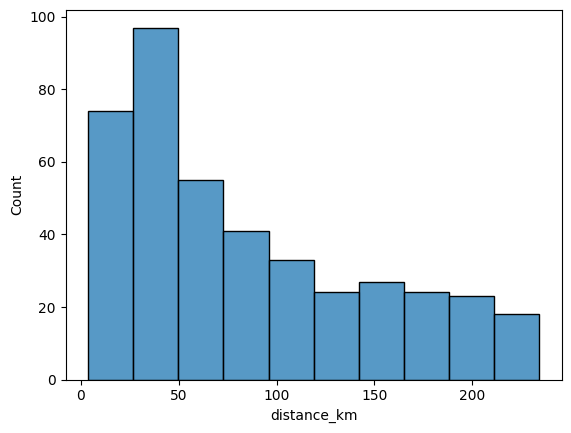

In [62]:
# distances of the solar sensors to the nearest weather station
sns.histplot(om_dwd_hourly_dist_df.distance_km)
plt.show()

In [63]:
# max distance to a weather sensor
om_dwd_hourly_dist_df.distance_km[om_dwd_hourly_dist_df.distance_km!=float("inf")].max()

234.21357783909747

In [64]:
# sensors with nearby dwd weather station (<10km)
om_dwd_hourly_dist_df[om_dwd_hourly_dist_df.distance_km < 10].sort_values(by="distance_km")

,plz,city,state,sensor_id,start_date,end_date,num,lon,lat,distance_km,dwd_stat_name,dwd_stat_lon,dwd_stat_lat,dwd_stat_id
94,01129,Dresden,Sachsen,2039474a-7597-4aff-bb4a-62abf4015de3,2021-04-20,2023-05-24,1,13.7360,51.0967,3.690707,Dresden-Klotzsche,13.7543,51.1278,1048.0
366,54317,Thomm,Rheinland-Pfalz,b5465c4a-2148-4ae9-975f-3a93b7bcdc61,2022-12-11,2023-05-24,1,6.7322,49.7617,5.532381,Trier-Petrisberg,6.6583,49.7479,5100.0
154,22391,Hamburg Ohlsdorf,Hamburg,889f8e49-307d-448c-871d-378500939997,2021-05-11,2023-05-24,1,10.0742,53.6564,6.241079,Hamburg-Fuhlsbüttel,9.9881,53.6332,1975.0
186,24879,Idstedt,Schleswig-Holstein,08120e03-dc8e-407e-9169-0998585d1108,2021-03-17,2023-05-24,1,9.5167,54.5833,6.546128,Schleswig,9.5487,54.5275,4466.0
187,24879,Idstedt,Schleswig-Holstein,d82b675e-9e9e-4692-b640-62e5c8f48345,2022-07-14,2023-05-24,1,9.5167,54.5833,6.546128,Schleswig,9.5487,54.5275,4466.0
241,68219,Mannheim,Baden-Wuerttemberg,6037b10c-1b42-4ea4-b13b-c8582436df9e,2022-07-14,2023-07-05,1,8.4647,49.4883,7.064649,Mannheim,8.5584,49.5063,5906.0
242,68219,Mannheim,Baden-Wuerttemberg,34f950a5-2f9a-473d-a98f-d15391a1e3c3,2020-02-17,2023-07-05,1,8.4647,49.4883,7.064649,Mannheim,8.5584,49.5063,5906.0
243,68219,Mannheim,Baden-Wuerttemberg,7e5a0892-596c-4576-986d-396dd1cae4d0,2020-02-14,2023-07-05,1,8.4647,49.4883,7.064649,Mannheim,8.5584,49.5063,5906.0
245,68219,Mannheim,Baden-Wuerttemberg,a4da749e-d457-4f3b-9ecd-e659b3f7355c,2020-02-14,2023-05-24,1,8.4647,49.4883,7.064649,Mannheim,8.5584,49.5063,5906.0
247,68239,Mannheim,Baden-Wuerttemberg,9e6715b8-076c-43b1-9119-f3f424beacbf,2022-07-14,2023-05-24,1,8.4647,49.4883,7.064649,Mannheim,8.5584,49.5063,5906.0


### Map view of OM PV sensor locations and DWD weather stations

In [65]:
# co-localization of OM PV sensors and DWD weather stations
# colored = solar data
temp_df = om_dwd_daily_dist_df[om_dwd_daily_dist_df.distance_km < 10].copy()
temp_df["marker"] = 5
fig1 = px.scatter_mapbox(temp_df,
                         lat="dwd_stat_lat", lon="dwd_stat_lon", 
                         hover_name="city", hover_data=["dwd_stat_id"], 
                         center=dict(lat=51.3, lon=10.5), # center map on Germany
                         zoom=5, width=800, height=600,
                         opacity=0.99, size="marker", color="distance_km")#, color_discrete_sequence=["darkblue"])#, color="column")
# fig1.update_traces(marker_sizemode='area', marker_sizeref=50)
# black/gray = weather data
fig2 = px.scatter_mapbox(recent_long_daily_data, lat="geoBreite", lon="geoLaenge", 
                         hover_name="Stationsname", #hover_data=["col1", "col2"], 
                         zoom=5, width=800, height=600, 
                         opacity=0.99, color_discrete_sequence=["black"])#, color="column")

# combine figures and update layout
fig1.add_trace(fig2.data[0])
fig1.update_layout(mapbox_style="open-street-map")
fig1.update_layout(margin={"r":10,"t":10,"l":10,"b":10}) # white margin around figure
fig1.show()


In [66]:
# co-localization of OM PV sensors and DWD weather stations
# colored = solar data
temp_df = om_dwd_hourly_dist_df[om_dwd_hourly_dist_df.distance_km < 20].copy()
temp_df["marker"] = 5
fig1 = px.scatter_mapbox(temp_df,
                         lat="dwd_stat_lat", lon="dwd_stat_lon", 
                         hover_name="city", hover_data=["dwd_stat_id"], 
                         center=dict(lat=51.3, lon=10.5), # center map on Germany
                         zoom=5, width=800, height=600,
                        #  size=10*len(om_dwd_hourly_dist_df), # marker size
                         opacity=0.99, size="marker", color="distance_km")#, color_discrete_sequence=["darkblue"])#
# fig1.update_traces(marker_sizemode='area', marker_sizeref=50)

# black = weather data
fig2 = px.scatter_mapbox(dwd_locations_hourly_df, lat="geoBreite", lon="geoLaenge", 
                         hover_name="Stationsname", #hover_data=["col1", "col2"], 
                         zoom=5, width=800, height=600, 
                         opacity=0.99, color_discrete_sequence=["black"])#, color="column")

# combine figures and update layout
fig1.add_trace(fig2.data[0])
fig1.update_layout(mapbox_style="open-street-map")
fig1.update_layout(margin={"r":10,"t":10,"l":10,"b":10}) # white margin around figure
fig1.show()


### Create output file with OpenMeter PV data linked to DWD weather data

In [67]:
# create output directory, if required
out_path = "../data/omp_data/"
if not os.path.exists(out_path):
   os.makedirs(out_path)

om_dwd_daily_dist_df.sort_values(by="distance_km").to_csv(out_path+"OpenMeter_weather_daily.csv")
om_dwd_hourly_dist_df.sort_values(by="distance_km").to_csv(out_path+"OpenMeter_weather_hourly.csv")